In [1]:
import os

import matplotlib as mpl
import numpy as np
from cil.framework import ImageGeometry
from cil.io import TIFFWriter
from cil.io.TIFF import TIFFWriter
from cil.plugins.astra import FBP
from cil.processors import TransmissionAbsorptionConverter

# from cil.recon import FBP, FDK
from cil.utilities.display import show2D
from gvxrPython3 import gvxr
from matplotlib import pyplot as plt
from RXSolutionsDataReader import RXSolutionsDataReader
from utils import (
    find_optimal_stepwedge_size,
    find_optimal_stepwedge_size_mixture,
    get_optimal_poly_fit,
    setPolySpectrum,
    transmission_to_absorption,
)

# Configure matplotlib graph
font = {
    "family": "serif",
    "size": 15,
}
mpl.rc("font", **font)

# Uncomment the line below to use LaTeX fonts
# matplotlib.rc('text', usetex=True)

# Move all gVXR logs to a file
gvxr.useLogFile("beam-hardening.log")

xpecgen is not install, you won't be able to load a beam spectrum using xpecgen


In [2]:
# -------------------------------------
# I/O
# -------------------------------------
INPUT_PATH = "../../../data-rx/260kV_noFilter"
OUTPUT_PATH = "../../output_data/beam-hardening/rx-sol"

# -------------------------------------
# Focus on highest attenuating material
# -------------------------------------

# material_of_sample = "Cu"

material_of_sample = {
    "elements": [1, 6, 7, 8, 16, 20],
    "weights": [0.026714, 0.057594, 0.011194, 0.527378, 0.167620, 0.209501],
    "density": 1.7,
}

# -----------------------------
# Units
# -----------------------------
unit_of_length : str = "mm"
tube_voltage_unit : str = "kV"
energy_unit : str = "keV"

# -----------------------------
# Spectrum Characteristics
# -----------------------------
tube_angle_degrees : float = 12.0
tube_voltage_kV : float = 260

# -----------------------------
# Filter Characteristics
# -----------------------------
# filters = ["Ag", 0.25, unit_of_length]
# filters = [["Ag", 0.25, unit_of_length], ["Mo", 1, unit_of_length]]
filters = None

# -----------------------------
# Detector Scintillator
# -----------------------------
# scintillator = None
scintillator = {
    "material": "Gd2O2S DRZ-Plus",
    "thickness": 210,
    "unit": "um",
}

# 1. Read data in

In [3]:
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

In [4]:
number_of_slices_to_reconstruct = 0 # Use 0 to compute it automatically
scaling_factor = 2

if scaling_factor == 1:
    roi = None
else:
    roi = {"axis_1": [None, None, scaling_factor], "axis_2": [None, None, scaling_factor]}

CSV_file_path_1 = os.path.join(INPUT_PATH, "geometry.csv")
CSV_file_path_2 = os.path.join(INPUT_PATH, "geom.csv")

if os.path.exists(CSV_file_path_1):
    CSV_file_path = CSV_file_path_1
elif os.path.exists(CSV_file_path_2):
    CSV_file_path = CSV_file_path_2
else:
    raise OSError(CSV_file_path_1 + " and " + CSV_file_path_2 + " do not exist")

In [5]:
reader = RXSolutionsDataReader(CSV_file_path, roi=roi)

In [6]:
flexible_acq_data = reader.read()

# Pre-processing and Reconstruction

In [7]:
# Prepare the data for Astra
flexible_acq_data.reorder(order="astra")

flexible_data_exp = TransmissionAbsorptionConverter()(flexible_acq_data)

In [8]:
# Use the system magnification to compute the voxel size
mag = flexible_data_exp.geometry.magnification
mean_mag = np.mean(mag)

print("Mean magnification: ", mean_mag)

voxel_size_xy = flexible_data_exp.geometry.config.panel.pixel_size[0] / mean_mag
voxel_size_z = flexible_data_exp.geometry.config.panel.pixel_size[1] / mean_mag

voxel_size_xy = min(voxel_size_xy, voxel_size_z)
voxel_size_z = voxel_size_xy

# Create an image geometry
num_voxel_xy = int(np.ceil(flexible_data_exp.geometry.config.panel.num_pixels[0]))
num_voxel_z = int(np.ceil(flexible_data_exp.geometry.config.panel.num_pixels[1]))

if number_of_slices_to_reconstruct > 0:
    num_voxel_z = number_of_slices_to_reconstruct // scaling_factor

image_geometry = ImageGeometry(
    num_voxel_xy, num_voxel_xy, num_voxel_z,
    voxel_size_xy, voxel_size_xy, voxel_size_z,
)

print(image_geometry)

Mean magnification:  2.405202982025755
Number of channels: 1
channel_spacing: 1.0
voxel_num : x718,y718,z718
voxel_size : x0.12472993404032942,y0.12472993404032942,z0.12472993404032942
center : x0,y0,z0



In [9]:
# Reconstruct using FDK
# Instantiate the reconstruction algorithm
fdk = FBP(image_geometry, flexible_data_exp.geometry)
fdk.set_input(flexible_data_exp)

# Perform the actual CT reconstruction
flexible_recon = fdk.get_output()

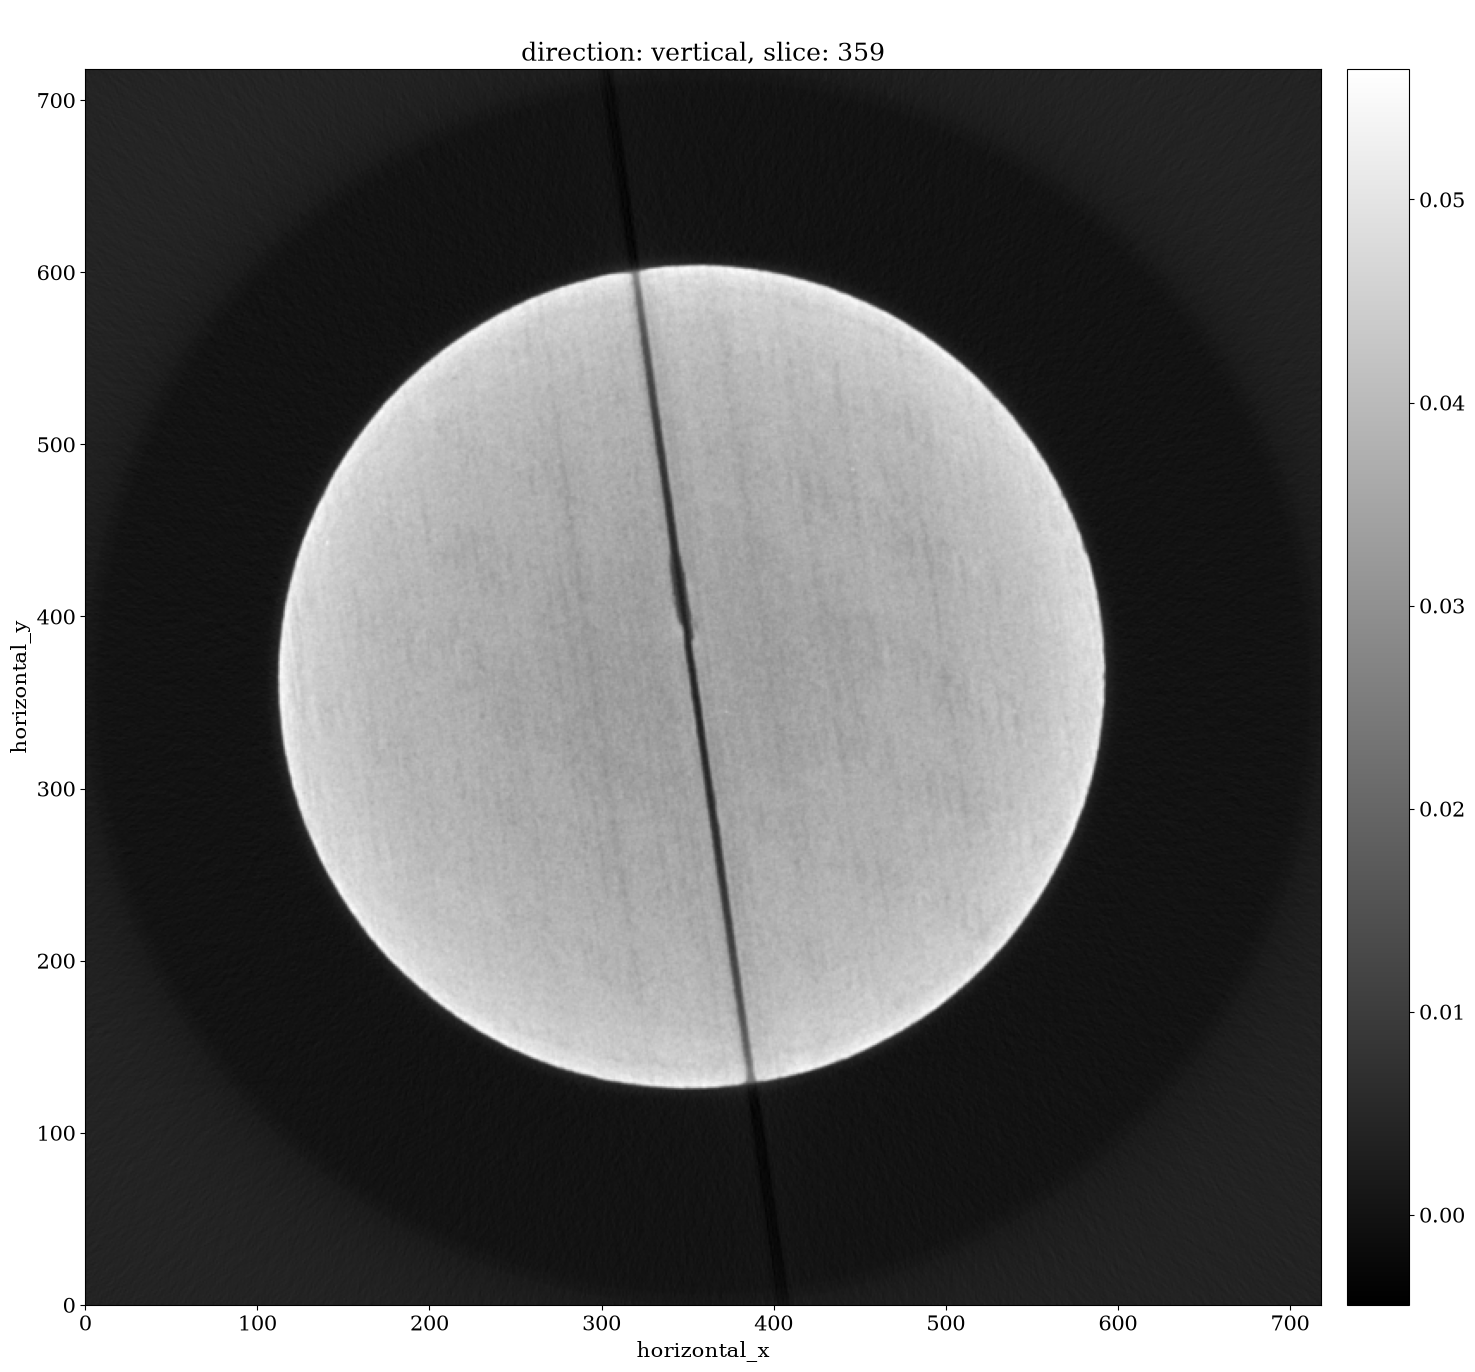

In [10]:
show2D(flexible_recon)

# 2. Setup the source spectrum and material
To ensure the gVXR simulations match the experimental parameters, configure the settings provided.

In this case, the `.mat` file is extensive enough to cover most of the required data but in the case where the information is not available in the file, the parameters should be input (see `tube_angle_degrees`).

Most importantly, include the material of the sample that most closely resembles the material of the sample being scanned. In the case of the HTC data, this material was Aluminium.

In [11]:
# ---------------------------------------------------------------
# Geometry specific values
# ---------------------------------------------------------------
scan_geometry = flexible_data_exp.geometry.geom_type

# Counted from perpendicular of ray to detector
detector_origin_distance = np.mean(flexible_data_exp.geometry.dist_center_detector)
source_origin_distance = np.mean(flexible_data_exp.geometry.dist_source_center)

detector_rows, detector_columns = (
    num_voxel_xy,
    num_voxel_xy,
)

pixel_size = (
    flexible_data_exp.geometry.pixel_size_h,
    flexible_data_exp.geometry.pixel_size_v,
)

In [12]:
print(
    f"""
---------------------------------------------------------------
Table of extracted data
---------------------------------------------------------------
| Geometry                  | {scan_geometry}
---------------------------------------------------------------
Distances
---------------------------------------------------------------
| Source-Origin distance    | {source_origin_distance:.2f} {unit_of_length}
| Detector-Origin distance  | {detector_origin_distance:.2f} {unit_of_length}
---------------------------------------------------------------
Detector Characteristics
---------------------------------------------------------------
| Number of pixels          | {detector_rows}x{detector_columns}
| Pixel size (post-binning) | {[float(i) for i in pixel_size]} {unit_of_length}
---------------------------------------------------------------
Source Characteristics
---------------------------------------------------------------
| Tube Voltage              | {tube_voltage_kV} {tube_voltage_unit}
| Tube Angle (degrees)      | {tube_angle_degrees}
---------------------------------------------------------------
Filters
---------------------------------------------------------------
| Filter list               | {filters}
| Tube Angle (degrees)      | {tube_angle_degrees}
"""
)


---------------------------------------------------------------
Table of extracted data
---------------------------------------------------------------
| Geometry                  | CONE_FLEX
---------------------------------------------------------------
Distances
---------------------------------------------------------------
| Source-Origin distance    | 399.55 mm
| Detector-Origin distance  | 561.45 mm
---------------------------------------------------------------
Detector Characteristics
---------------------------------------------------------------
| Number of pixels          | 718x718
| Pixel size (post-binning) | [0.30000080930167605, 0.30000080930167605] mm
---------------------------------------------------------------
Source Characteristics
---------------------------------------------------------------
| Tube Voltage              | 260 kV
| Tube Angle (degrees)      | 12.0
---------------------------------------------------------------
Filters
---------------------------

In [13]:
gvxr.createOpenGLContext()

pci id for fd 127: 10de:1eb1, driver (null)
pci id for fd 128: 10de:1eb1, driver (null)
pci id for fd 127: 10de:1eb1, driver (null)
pci id for fd 128: 10de:1eb1, driver (null)
pci id for fd 127: 10de:1eb1, driver (null)
pci id for fd 128: 10de:1eb1, driver (null)
pci id for fd 127: 10de:1eb1, driver (null)
pci id for fd 128: 10de:1eb1, driver (null)


In [14]:
source_position = (-source_origin_distance, 0, 0)
detector_position = (detector_origin_distance, 0, 0)
detector_up_vector = (0, 0, -1)

# Detector Position and direction
gvxr.setDetectorPosition(*detector_position, unit_of_length)
gvxr.setDetectorUpVector(*detector_up_vector)

gvxr.setDetectorNumberOfPixels(detector_columns, detector_rows)
gvxr.setDetectorPixelSize(*pixel_size, unit_of_length)

if scintillator:
    gvxr.setScintillator(
        scintillator["material"],
        scintillator["thickness"],
        scintillator["unit"],
    )

# 3. Mirror the polychromatic X-ray source used in reconstruction

In [15]:
poly_spectrum_hist = setPolySpectrum(
    tube_voltage_kV,
    filters=filters,
    tube_angle_in_deg=tube_angle_degrees,
    unit=energy_unit,
)

poly_spectrum_bins, poly_spectrum_photons = poly_spectrum_hist

# Source position
gvxr.setSourcePosition(
    *source_position,
    unit_of_length,
)

# Source type
# For the case for getting look up table values, the Parallel geometry is
# the easiest to work with and gives a good enough range to work with.
gvxr.useParallelBeam()

In [16]:
average_energy = np.sum(np.array(poly_spectrum_photons) * np.array(poly_spectrum_bins)) / np.sum(poly_spectrum_photons)

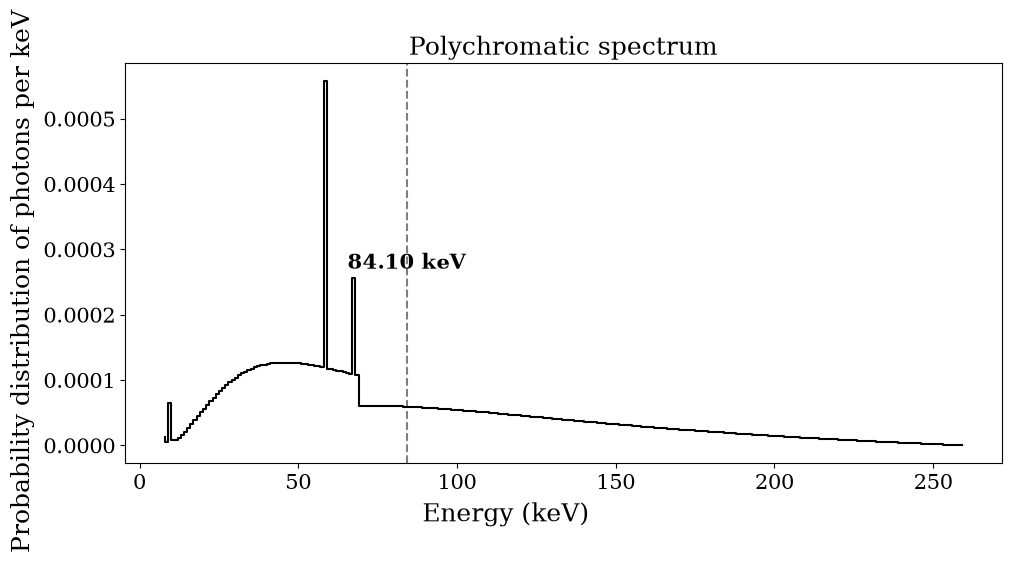

In [17]:
fig = plt.figure(figsize=(10, 5), constrained_layout=True)
fig.supxlabel(f"Energy ({energy_unit})")
fig.supylabel(f"Probability distribution of photons per {energy_unit}")

plt.title(f"Polychromatic spectrum")
plt.step(poly_spectrum_bins, poly_spectrum_photons, "k")

average_energy = np.sum(np.array(poly_spectrum_photons) * np.array(poly_spectrum_bins)) / np.sum(
    poly_spectrum_photons
)

plt.axvline(average_energy, linestyle="--", color="k", alpha=0.5)
y_min, y_max = plt.ylim()
y_mid = (y_min + y_max) / 2

plt.text(
    average_energy,
    y_mid,
    f"{average_energy:.2f} {energy_unit}",
    va="center",
    ha="center",
    fontsize=15,
    fontweight="bold",
)

plt.show()

In [18]:
detector_width, detector_height = gvxr.getDetectorSize(unit_of_length)

step_wedge_name = "step-wedge"
step_wedge_material = material_of_sample
number_of_steps = 50
step_wedge_length = detector_width
step_wedge_width = detector_height

if isinstance(step_wedge_material, str):
    print(f"Chosen element of step wedge = {step_wedge_material}")
    step_wedge_height = find_optimal_stepwedge_size(
        flexible_data_exp,
        step_wedge_material,
        tolerance=flexible_recon.array.max(),
        max_iterations=50,
    )
elif isinstance(step_wedge_material, dict):
    print(f"Chosen mixture of step wedge = {step_wedge_material}")
    step_wedge_height = find_optimal_stepwedge_size_mixture(
        flexible_data_exp,
        material_of_sample["elements"],
        material_of_sample["weights"],
        material_of_sample["density"],
        tolerance=flexible_recon.array.max()*0.01,
        max_iterations=50,
        unit=unit_of_length,
    )
else:
    msg = "Missing sample material"
    raise ValueError(msg)

step_height = step_wedge_height / number_of_steps

print(f"Chosen height of step wedge = {step_wedge_height:.2f} {unit_of_length}")

Chosen mixture of step wedge = {'elements': [1, 6, 7, 8, 16, 20], 'weights': [0.026714, 0.057594, 0.011194, 0.527378, 0.16762, 0.209501], 'density': 1.7}
Chosen height of step wedge = 51.79 mm


In [19]:
gvxr.removePolygonMeshesFromSceneGraph()

gvxr.makeStepWedge(
    step_wedge_name,
    number_of_steps,  # Number of steps
    step_wedge_length * 0.9, # A slight buffer to also include background dark values
    step_wedge_width * 0.9,
    step_height,
    step_height,
    unit_of_length,
)

gvxr.addPolygonMeshAsOuterSurface(step_wedge_name)

if isinstance(step_wedge_material, str):
    gvxr.setElement(step_wedge_name, step_wedge_material)
elif isinstance(step_wedge_material, dict):
    gvxr.setMixture(
        step_wedge_name,
        material_of_sample["elements"],
        material_of_sample["weights"],
    )
    gvxr.setDensity(step_wedge_name, material_of_sample["density"], "g.cm-3")
else:
    msg = "Missing sample material"
    raise ValueError(msg)

gvxr.rotateNode(step_wedge_name, 90, 0, 90)
gvxr.translateNode(
    step_wedge_name,
    0,
    0,
    -step_wedge_height * 0.5,
    unit_of_length,
)

In [20]:
x_ray_poly_image = (
    np.array(gvxr.computeXRayImage(), dtype=np.single) / gvxr.getTotalEnergyWithDetectorResponse()
)

# 4. Get a projection with the equivalent monochromatic energy

In [21]:
gvxr.setMonoChromatic(average_energy, energy_unit, 1000)

In [22]:
x_ray_mono_image = (
    np.array(gvxr.computeXRayImage(), dtype=np.single) / gvxr.getTotalEnergyWithDetectorResponse()
)

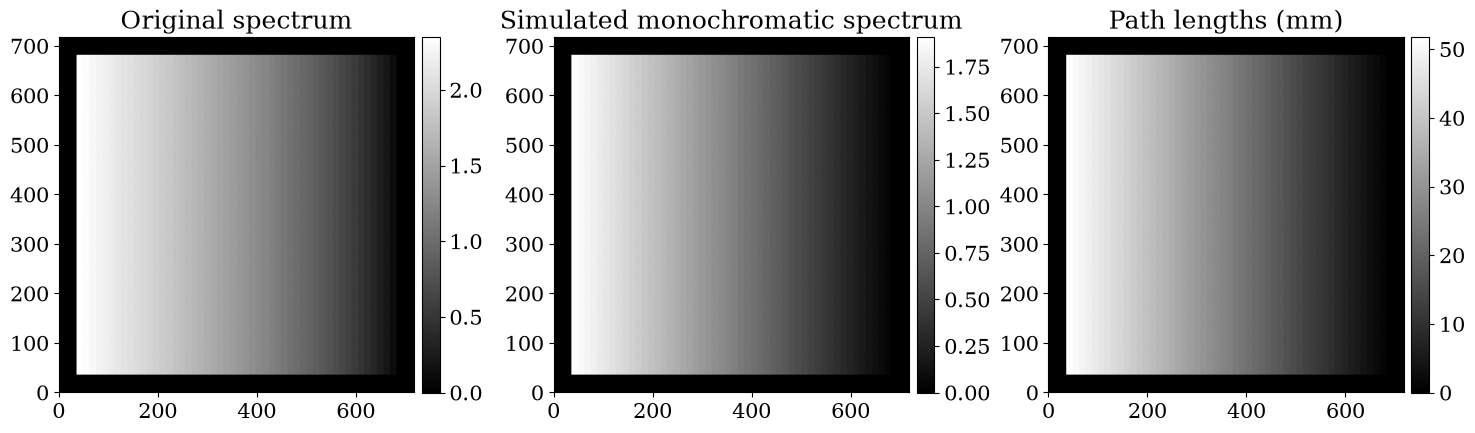

In [23]:
x_ray_L_buffer_cm = np.array(gvxr.getLastLBuffer(), dtype=np.single)                                    # The L-Buffer is in cm by default
x_ray_L_buffer = x_ray_L_buffer_cm * gvxr.getUnitOfLength("cm") / gvxr.getUnitOfLength(unit_of_length)  # L-Buffer in required units


x_ray_mono_image_absorption = transmission_to_absorption(x_ray_mono_image)  # Monochromatic source projection
x_ray_poly_image_absorption = transmission_to_absorption(x_ray_poly_image)  # Scan reconstruction

show2D(
    [x_ray_poly_image_absorption, x_ray_mono_image_absorption, x_ray_L_buffer],
    ["Original spectrum", "Simulated monochromatic spectrum", f"Path lengths ({unit_of_length})"],
    num_cols = 3,
)

# 5. Polychromatic fitting of spectra

In [24]:
lookup_table_indices = np.argsort(np.ravel(x_ray_poly_image_absorption))
polychromatic_sorted_values = np.ravel(x_ray_poly_image_absorption)[lookup_table_indices]
monochromatic_sorted_values = np.ravel(x_ray_mono_image_absorption)[lookup_table_indices]

L_buffer_sorted_values = np.ravel(x_ray_L_buffer)[lookup_table_indices]

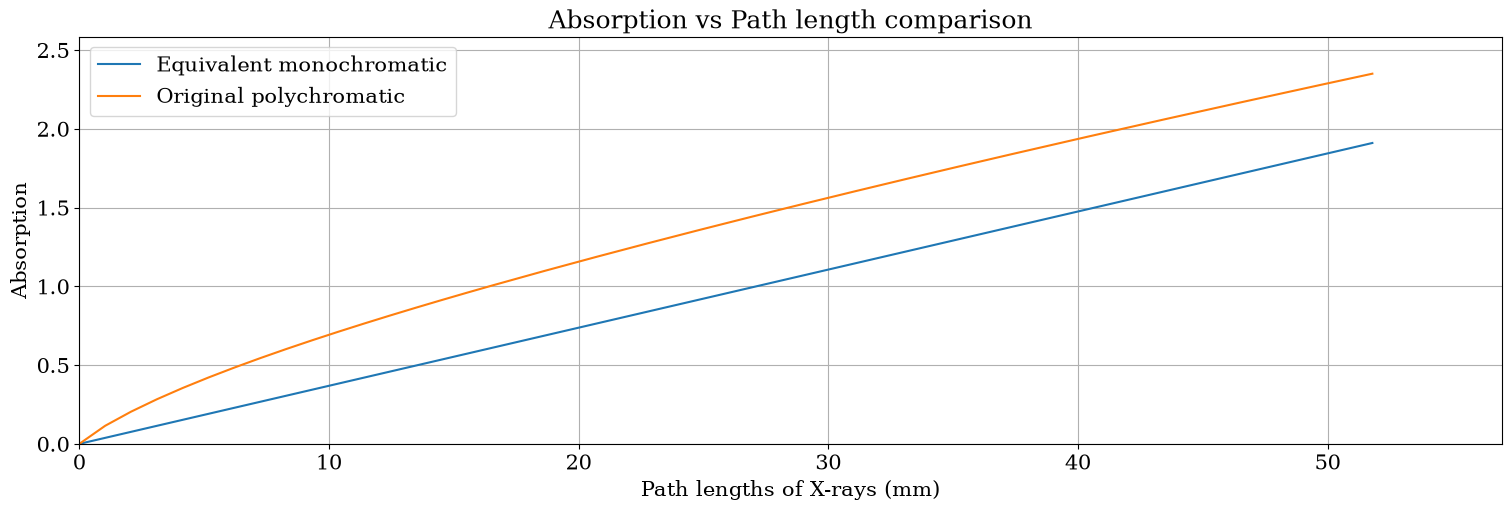

In [25]:
max_L_buffer = max(L_buffer_sorted_values)
max_absorption = np.max((monochromatic_sorted_values, polychromatic_sorted_values))

plt.close("all")

fig = plt.figure(figsize=(15, 5), constrained_layout=True)
plt.plot(
    L_buffer_sorted_values, monochromatic_sorted_values, label="Equivalent monochromatic"
)
plt.plot(
    L_buffer_sorted_values, polychromatic_sorted_values, label="Original polychromatic"
)
plt.legend()
plt.grid(True)
plt.title("Absorption vs Path length comparison")
plt.xlabel(f"Path lengths of X-rays ({unit_of_length})")
plt.ylabel("Absorption")
plt.xlim(0,max_L_buffer + 0.1 * max_L_buffer)
plt.ylim(0,max_absorption + 0.1 * max_absorption)
plt.show()

In [26]:
monochromatic_coefficients = np.polynomial.polynomial.polyfit(
    L_buffer_sorted_values,
    monochromatic_sorted_values,
    1,
)

order_limit = 10

fitted_polychromatic_values = get_optimal_poly_fit(
    L_buffer_sorted_values,
    polychromatic_sorted_values,
    order_limit,
)

/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly con

# 6. The CIL Beam hardening correction processor

In [27]:
copy_aq_data = flexible_data_exp.copy()

In [28]:
from BeamHardeningCorrector import BeamHardeningCorrector
from cil.utilities.display import show2D

max_path_length = step_wedge_height / gvxr.getUnitOfLength(unit_of_length)

processor = BeamHardeningCorrector(
    fitted_polychromatic_values.coefficients,
    monochromatic_coefficients[1],
    max_path_length,
    max_path_length * 0.01,
)

processor.set_input(copy_aq_data)
corrected_aq_data = processor.get_output()

In [29]:
fdk = FBP(image_geometry, flexible_data_exp.geometry)
fdk.set_input(corrected_aq_data)

# Perform the actual CT reconstruction
corrected_recon = fdk.get_output()

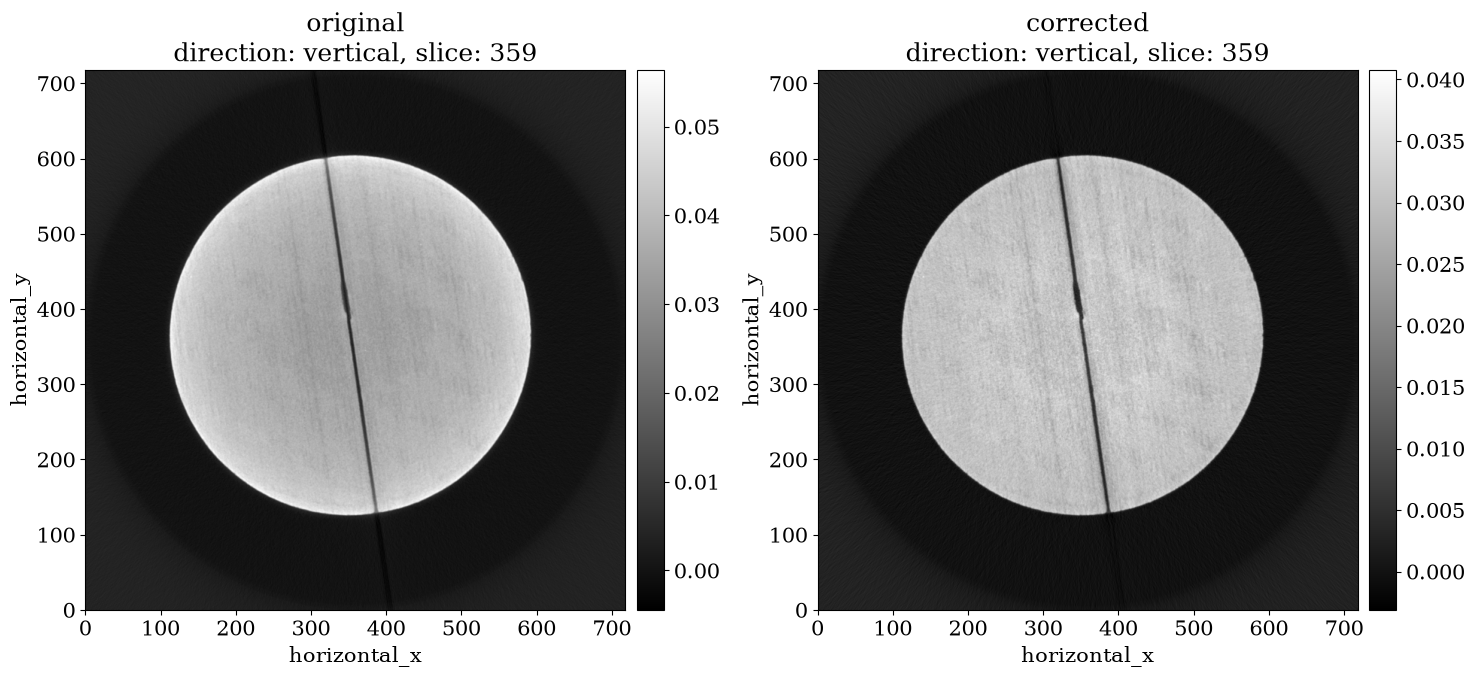

In [30]:
show2D([flexible_recon, corrected_recon], ["original", "corrected"])

In [31]:
o_writer = TIFFWriter(flexible_recon, os.path.join(OUTPUT_PATH, "orig_recon"))
o_writer.write()

c_writer = TIFFWriter(corrected_recon, os.path.join(OUTPUT_PATH, "corr_recon"))
c_writer.write()